# Processing data from the C++ program in ../bin/ising

The program computes the two-point function of the Ising model on a torus, starting from an odd state under $\mathbb Z_2$ symmetry.
The goal is to check whether the leading eigenvalue in this sector is indeed the one corresponding to the degenerate field $V_{(1, 1)}$.

In [1]:
using Plots
using Polynomials
using Symbolics
using JLD2

res_dir = "/Users/Paul/Documents/Recherche/projet_these/TransferMatricesCpp/models/ising/results";
cd(res_dir)

We compute the quantity

$$ \frac{1}{M} \log  \frac{\langle\sigma | T(L)^M |\sigma\rangle}{\langle \sigma | \sigma \rangle}  \underset{M\to \infty}{\to} \log\Lambda$$

where $M$ is the cylinder length, $L$ the cylinder perimeter, $T$ the transfer matrix, $\sigma$ the initial state, and $\Lambda$ the leading eigenvalue in the $\mathbb Z_2$ odd sector. The numbers produced by the C++ program are the $\langle \sigma | T(L)^M |\sigma \rangle$.

We extract the conformal dimension via the formula

$$ -\frac{1}{L} \log(\frac{\Lambda(L)}{\Lambda_0(L)}) = \frac{2\pi\Delta}{L^2} + o(L^{-2}). $$

Here, $\Delta$ is the conformal dimension of the operator which is the thermodynamic limit of the state corresponding to the eigenvalue $\Lambda$, and $\Lambda_0$ is the leading eigenvalue of the transfer matrix $T$ (the full transfer matrix, not only in the antisymmetrised sector).

## Checking the central charge

We start by checking the central charge, which we get as

$$ -\frac1L\log \Lambda_0(L) = f_0^\infty - \frac{\pi c}{6L^2} $$

In [2]:
# load the data
Λs = load("evs_z2_sym_sector.jld2", "Λs")
Λ0(L) = Λs[L][1];

0.49987105208026134


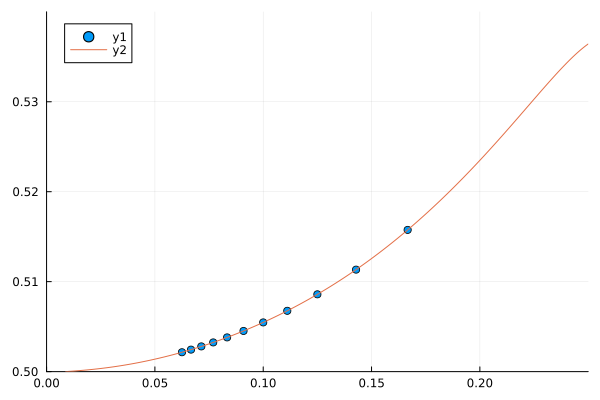

In [3]:
@variables c1, c2

f0(L) = -log(real(Λ0(L)))/L

# get and effective central charge from sizes L and L+1
eq(L) = c1 - π*c2/6/L^2 - f0(L)
c_eff(L) = Symbolics.solve_for([eq(L), eq(L+1)], [c1, c2])[2]

Lrange = 6:16
c_effs = [c_eff(L) for L in Lrange]
Ls = 1 ./ Lrange

# interpolate the central charges to infinite size
deg = length(Lrange)-1
p0 = fit(Ls, c_effs)
println(p0(0))

# Plot to check soundness
xfine = 0:0.001:0.25
scatter(Ls, c_effs)
plot!(xfine, p0.(xfine), xlims=(0, 0.25), ylims=(0.5, 0.54))

# Spin operator

Since the transfer matrix of the Ising model commutes with the $\mathbb Z_2$ spin-flip symmetry $\eta$, one can block-diagonalise $T$ in eigenspaces of $\eta$.

In [4]:
# load the data
Λ1s = load("highest_evs.jld2", "Λ1s")
Λ1(L) = Λ1s[L-3];

0.12499554614545368


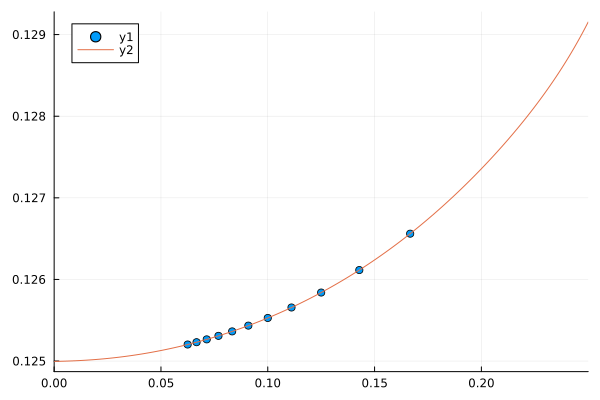

In [5]:
@variables Δ

f1(L) = -log(real(Λ1(L)))/L

# get an effective central charge from sizes L and L+1
eq(L) = f1(L)-f0(L) - π*Δ*2/L^2
Δ_eff(L) = Symbolics.value(Symbolics.solve_for(eq(L), Δ))

Lrange = 6:16
Δ_effs = [Δ_eff(L) for L in Lrange]
Ls = 1 ./ Lrange

# interpolate the central charges to infinite size
deg = length(Lrange)-1
p1 = fit(Ls, Δ_effs)
println(p1(0))

# Plot to check soundness
xfine = 0:0.001:0.25
scatter(Ls, Δ_effs)
plot!(xfine, p1.(xfine), xlims=(0, 0.25))

We find that the leading eigenvector in the antisymmetric sector converges to a field of dimension $\frac18$, this is the spin operator $V_{\langle 1, 2 \rangle}$ of the Ising model.

The current $V_{\langle 1, 1 \rangle}$ that we are looking for is located in the symmetric sector. Let us look for it.

## Current operator

I compute and interpolate the first few eigenvalues in the symmetric sector, looking for the current operator (=energy operator in the Ising model?)

In [6]:
Λ(i, L) = Λs[L][i]

Λ (generic function with 1 method)

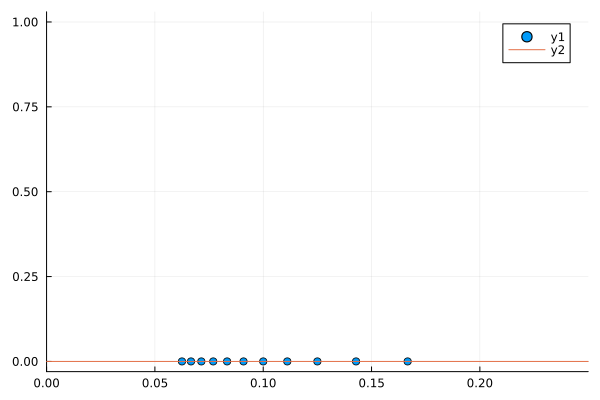

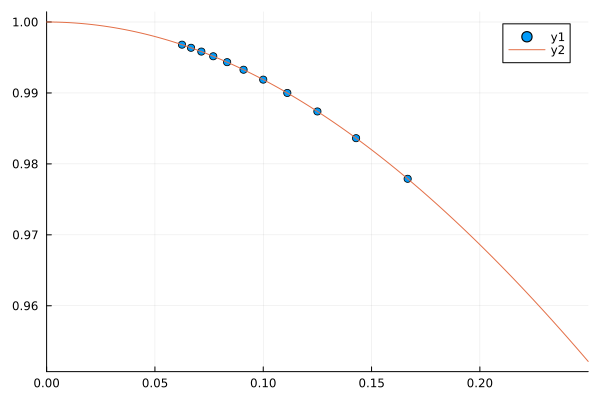

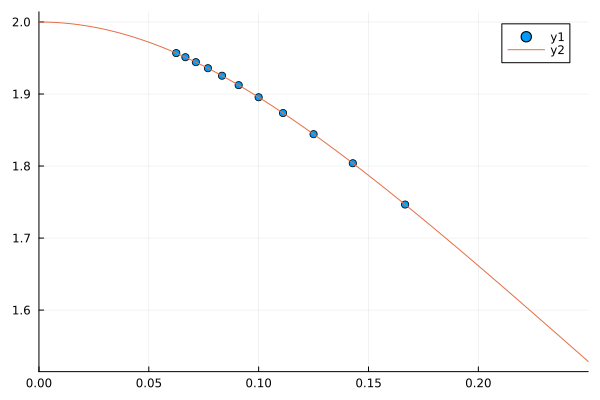

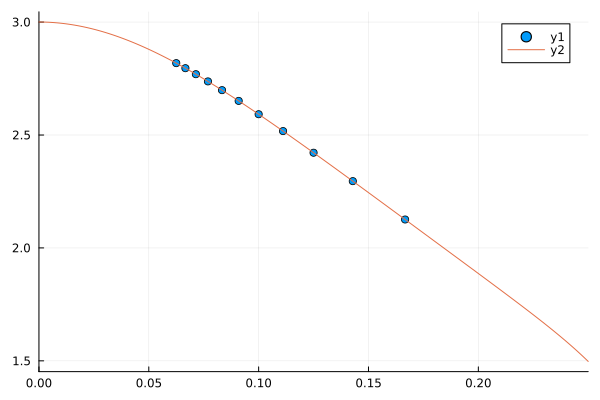

In [7]:
@variables Δ

f(i, L) = -log(real(Λ(i, L)))/L

# get an effective dimension from sizes L and L+1
eq(i, L) = f(i, L)-f0(L) - π*Δ*2/L^2
Δ_eff(i, L) = Symbolics.value(Symbolics.solve_for(eq(i, L), Δ))

Lrange = 6:16
Δ_eff(i) = [Δ_eff(i, L) for L in Lrange]
Ls = 1 ./ Lrange

# interpolate the conformal dimension to infinite size
deg = length(Lrange)-1
p(i) = fit(Ls, Δ_eff(i))

# Plot to check soundness
xfine = 0:0.001:0.25
for i in 1:4
    scatter(Ls, Δ_eff(i))
    plot!(xfine, p(i).(xfine), xlims=(0, 0.25))
    display(plot!())
end

spectrum = [p(i)(0) for i in 1:4];

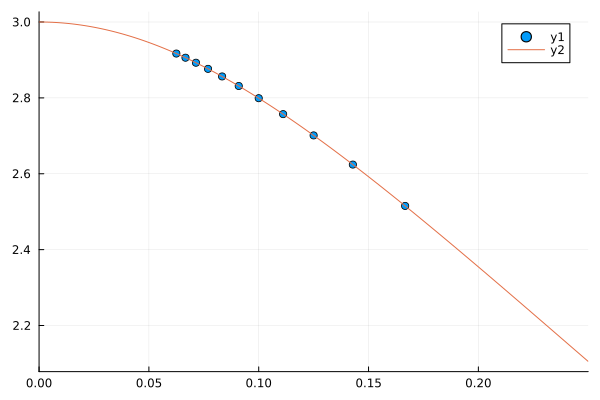

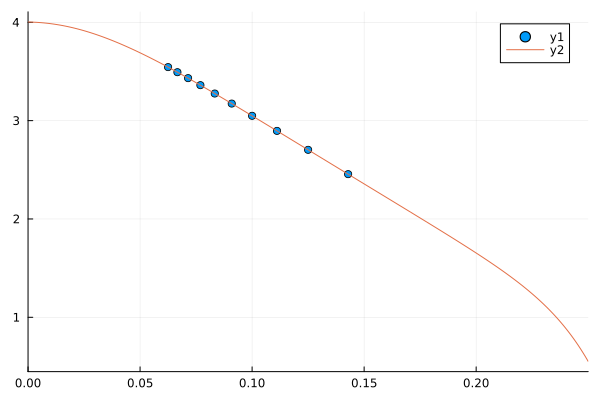

In [8]:
# manually correct level crossings
i=5
ind(L) = L-Lrange[1]+1 # index of the Δ_eff table corresponding to L

Δs5 = [Δ_eff(i, L) for L in Lrange]
Δs5[ind(13)] = Δ_eff(6, 13)
Δs5[ind(7)] = Δ_eff(6, 7)
scatter(Ls, Δs5)
p5 = fit(Ls, Δs5)
plot!(xfine, p5.(xfine), xlims=(0, 0.25))
display(plot!())
push!(spectrum, p5(0))

i=6
Δs6 = [Δ_eff(i, L) for L in Lrange]
Δs6[ind(13)] = Δ_eff(7, 13)
Δs6[ind(7)] = Δ_eff(5, 7)
scatter(Ls[2:end], Δs6[2:end])
p6 = fit(Ls[2:end], Δs6[2:end])
plot!(xfine, p6.(xfine), xlims=(0, 0.25))
display(plot!())
push!(spectrum, p6(0));

In [9]:
spectrum = unique(spectrum)

6-element Vector{Float64}:
 0.0
 1.000000037176581
 1.9999936366380995
 3.00036065452041
 2.999987249942907
 4.003458981065689

We observe that the second highest eigenvector of the transfer matrix in the $\mathbb Z_2$ symmetric sector of the Ising model converges to a dimension 1 operator.

Since this operator has two descendents at level 2, it has to be the degenerate operator $V_{\langle 1, 3 \rangle}$.

## Check of numerical stability of two-point function

We check that if we start from a $\mathbb Z_2$ antisymmetric vector, and repeatedly act on it with the transfer matrix, the state we get is indeed dominated by the leading eigenvector of the antisymmetric sector.

In [21]:
L = 14
M = 1000

# lattice two-point function from the C++ program, using the regular Ising matrix
# acting on a Z_2 odd initial state.
B = 0.651103855261492*big"2"^18724
init_norm_sq = 2;

logΛ = 1/M*log(B/init_norm_sq)
exp(logΛ)

432512.0972599979466606914136784337626679855423679992558866737134348109861135431

In [17]:
Λas = load("evs_z2_antisym_sector.jld2", "Λs")
Λ0as(L) = Λas[L][1];
# leading eigenvalue in the antisymmetric sector
Λ0as(14)

432904.3591251789 + 0.0im

Indeed, there is no numerical instability, 